No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


(4,)


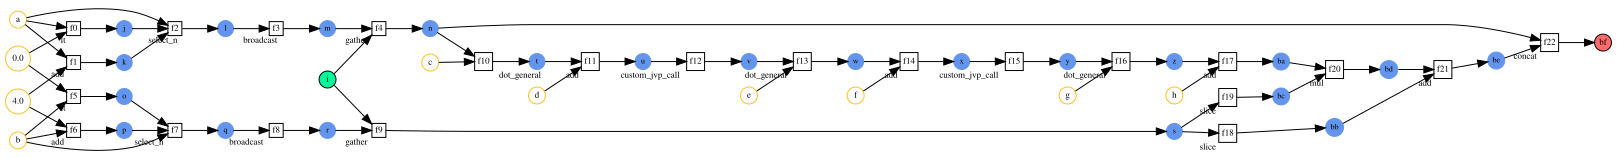

In [1]:
from probjax.core import inverse, inverse_and_logabsdet
from probjax.core.jaxpr_propagation.deprecated_graph import JaxprGraph

import jax
import jax.numpy as jnp
from typing import Callable, Sequence
from jaxtyping import Array

import haiku as hk

from probjax.core.custom_primitives.custom_inverse import custom_inverse

# Coupling like invertible

def coupling(mask: jnp.ndarray, conditionor: Callable[[Array], Array], transformer: Callable[[Array, Array], Array]):
    non_mask = ~mask
    def f(x):
        print(x.shape)
        # assert x.ndim == 1, "x must be 1D"
        # assert x.shape == mask.shape, "Shape of x and mask must match"
        x1 = x.at[mask].get()
        x2 = x.at[non_mask].get()
        y1 = x1
        y2 = transformer(x2, conditionor(x1))
        y = jnp.concatenate([y1, y2])
        return y
    
    return f

mask = jnp.array([True, True, False, False], dtype=jnp.bool_)
#conditionor = lambda x: x*2
def affine_transfomer(loc_and_scale,x):
    loc, scale = jnp.split(loc_and_scale, 2)
    return loc + scale * x
model = hk.without_apply_rng(hk.transform(lambda x: hk.nets.MLP([2,50, 4])(x)))
params = model.init(jax.random.PRNGKey(42), jnp.ones((2,)))
conditionor = lambda x: model.apply(params, x)
transformer = affine_transfomer
x = jnp.arange(4, dtype=jnp.float32) + 1

f = coupling(mask, conditionor, transformer)
jaxpr = jax.make_jaxpr(f)(x)
g = JaxprGraph(jaxpr.jaxpr.invars,jaxpr.jaxpr.constvars,  jaxpr.jaxpr.outvars, jaxpr.eqns)
g

In [2]:
from typing import Optional
from functools import partial



class Coupling(hk.Module):
    def __init__(self, split_index, bijector, num_bijector_params, hidden_dims = [50,], name=None):
        super().__init__(name=name)
        self.split_index = split_index
        self.bijector = bijector
        self.num_bijector_params = num_bijector_params
        self.hidden_dims = hidden_dims

    
    def __call__(self, x: Array) -> Array:
        conditionor = hk.nets.MLP([self.split_index,] + self.hidden_dims + [self.num_bijector_params])
        x1, x2 = jnp.split(x, [self.split_index], axis=-1)
        y1 = x1
        y2 = transformer(conditionor(x1), x2)
        y = jnp.concatenate([y1, y2], axis=-1)
        return y
    
class Flip(hk.Module):
    def __init__(self, axis:int = -1, name: str="reverse"):
        super().__init__(name=name)
        self.axis = axis

    def __call__(self, x: Array) -> Array:
        return jnp.flip(x, axis=self.axis)
        

@hk.without_apply_rng
@hk.transform
def f(x):
    #model = hk.Sequential([MaskedCoupling(mask, affine_transfomer, 4),
    #                       MaskedCoupling(~mask, affine_transfomer, 4)])
    model = hk.Sequential([Coupling(2, affine_transfomer, 4), Flip(), Coupling(2, affine_transfomer, 4)])
    return model(x)

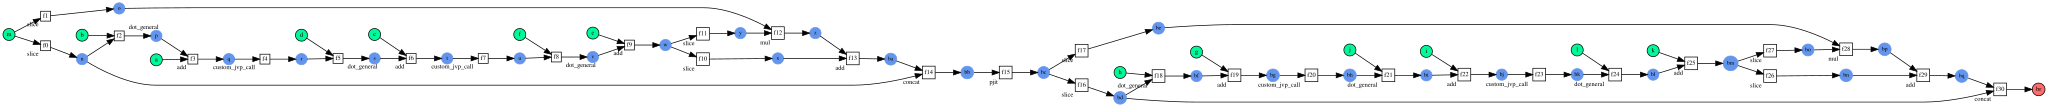

In [3]:
params = f.init(jax.random.PRNGKey(42), jnp.ones((4,)))

out = f.apply(params, jnp.arange(4, dtype=jnp.float32) + 1)
jaxpr = jax.make_jaxpr(f.apply)(params,x)
g = JaxprGraph(jaxpr.jaxpr.invars,jaxpr.jaxpr.constvars,  jaxpr.jaxpr.outvars, jaxpr.eqns)
g


In [4]:
f_inverse = inverse(f.apply, invertible_arg=-1)

In [7]:
out

Array([ 6.69 ,  5.033, -0.127, -0.27 ], dtype=float32)

In [6]:
f_inverse(params, out)

[a, b, c, d, e, f, g, h, i, j, k, l]


Array([1., 2., 3., 4.], dtype=float32)

[a, b, c, d, e, f, g, h, i, j, k, l]
Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=1/0)> Traced<ShapedArray(float32[2])>with<DynamicJaxprTrace(level=1/0)> 0
Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=1/0)> Traced<ShapedArray(float32[2])>with<DynamicJaxprTrace(level=1/0)> 2
Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=1/0)> Traced<ShapedArray(float32[2])>with<DynamicJaxprTrace(level=1/0)> 0
Traced<ShapedArray(float32[4])>with<DynamicJaxprTrace(level=1/0)> Traced<ShapedArray(float32[2])>with<DynamicJaxprTrace(level=1/0)> 2


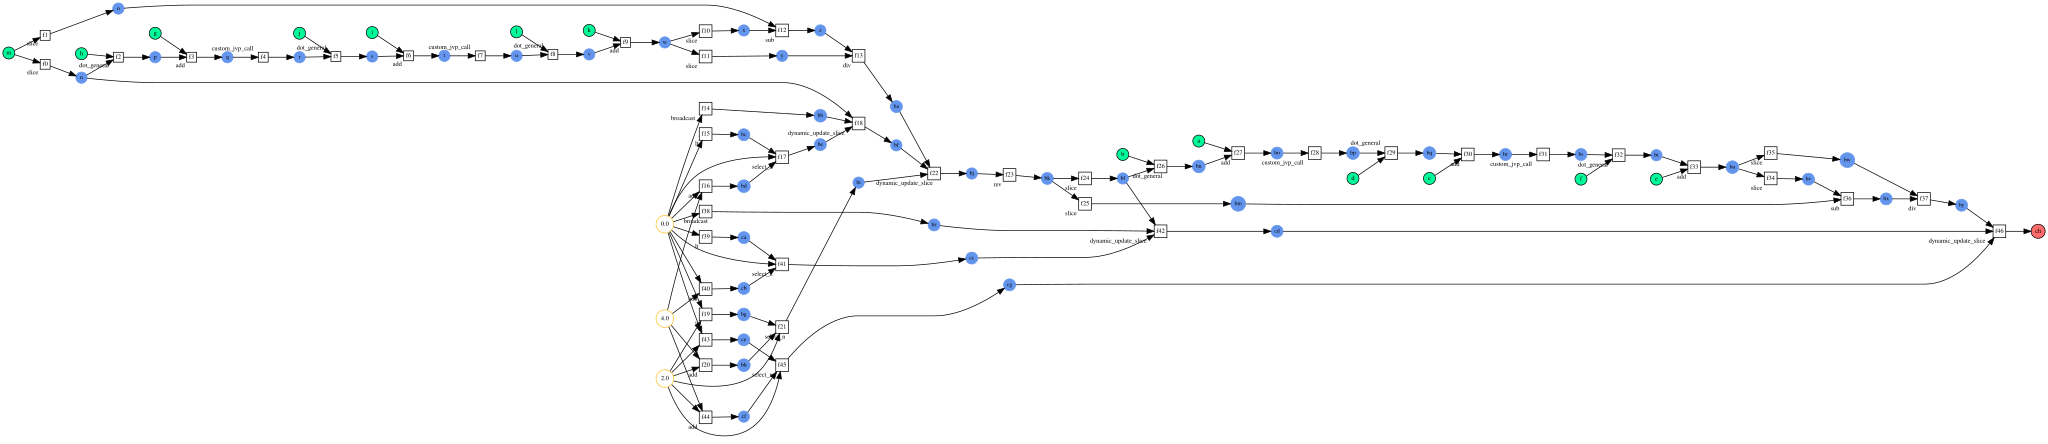

In [5]:
jaxpr = jax.make_jaxpr(f_inverse)(params,out)
g = JaxprGraph(jaxpr.jaxpr.invars,jaxpr.jaxpr.constvars,  jaxpr.jaxpr.outvars, jaxpr.eqns)
g


In [6]:
jax.lax.dynamic_update_slice(x, jnp.zeros(2), [jnp.asarray(0),])

Array([0., 0., 3., 4.], dtype=float32)

In [ ]:
jax.lax.dynamic_u

In [2]:
# def f(x):
#     x = 2*x
#     return jnp.tanh(x)

f_inv = inverse(f)
f_inv_det = inverse_and_logabsdet(f)


o = f(x)
f_inv(o)

f_inv_det(o)

(4,)
(Array([ 1.   ,  2.   , -3.781,  3.475, 11.971,  9.571], dtype=float32),)
(6,)


IndexError: boolean index did not match shape of indexed array in index 0: got (4,), expected (6,)

In [11]:
jnp.log(jnp.linalg.det(jax.jacfwd(f_inv)(o)))

(4,)


Array(-2.0794415, dtype=float32)

In [3]:

f_inv(0.5)

()


IndexError: boolean index did not match shape of indexed array in index 0: got (4,), expected ()

In [5]:
jnp.log(jax.jacfwd(f_inv)(0.5))

Array(-0.4054651, dtype=float32, weak_type=True)

In [14]:
jaxpr.jaxpr.invars[0].__slots__ += ("log_abs_det",)

AttributeError: 'Var' object attribute '__slots__' is read-only

In [24]:
jax.lax.log1p_p.bind(1.)

Array(0.6931472, dtype=float32, weak_type=True)

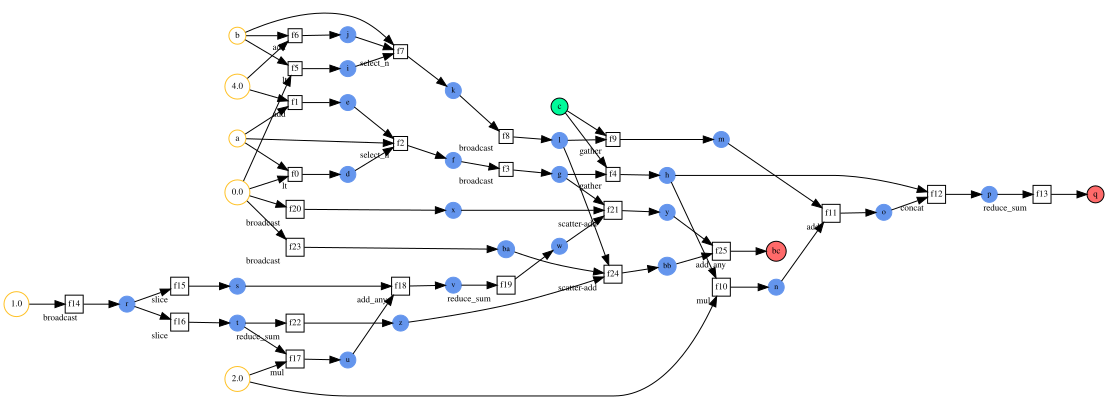

In [21]:
g = JaxprGraph(jac_grad.jaxpr.invars,jac_grad.jaxpr.constvars,  jac_grad.jaxpr.outvars, jac_grad.eqns)
g

In [3]:
jnp.sum(1.)

Array(1., dtype=float32)

In [18]:
J = jax.jacfwd(f)(x)
J

(4,)


Array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [6., 0., 2., 0.],
       [0., 8., 0., 4.]], dtype=float32)

In [7]:
def value_and_log_det_diagonal(f):
    # This assumes that the jacobian is diagonal!
    grad_fn = jax.value_and_grad(f_sum)
    
    def log_det_fn(*args, **kwargs):
        log_det = jnp.log(jnp.abs(grad_fn(*args, **kwargs)))
        return log_det.sum()
    return log_det_fn

def log_det_multivariate(f):
    jac_fn = jax.jacfwd(f)
    def log_det_fn(*args, **kwargs):
        jac = jac_fn(*args, **kwargs)
        log_det = jnp.log(jnp.abs(jnp.linalg.det(jac)))
        return log_det
    return log_det_fn


In [8]:
log_det_multivariate(f)(x)

(4,)


Array(2.0794415, dtype=float32)

In [35]:
f = jax.vmap(jax.value_and_grad(lambda x: jnp.sum(x*2)))
jax.make_jaxpr(f)(jnp.ones((10)))

{ lambda ; a:f32[10]. let
    b:f32[10] = mul a 2.0
    c:f32[10] = reduce_sum[axes=()] b
    d:f32[] = mul 1.0 2.0
    e:f32[10] = broadcast_in_dim[broadcast_dimensions=() shape=(10,)] d
  in (c, e) }

In [13]:
import jax
f = jax.value_and_grad(lambda x: jnp.sum(x**2)*x)
jax.make_jaxpr(f)(1.)

{ lambda ; a:f32[]. let
    b:f32[] = integer_pow[y=2] a
    c:f32[] = integer_pow[y=1] a
    d:f32[] = mul 2.0 c
    e:f32[] = convert_element_type[new_dtype=float32 weak_type=False] b
    f:f32[] = reduce_sum[axes=()] e
    g:f32[] = convert_element_type[new_dtype=float32 weak_type=False] a
    h:f32[] = mul f g
    i:f32[] = mul f 1.0
    j:f32[] = convert_element_type[new_dtype=float32 weak_type=True] i
    k:f32[] = mul 1.0 g
    l:f32[] = convert_element_type[new_dtype=float32 weak_type=True] k
    m:f32[] = mul l d
    n:f32[] = add_any j m
  in (h, n) }

In [ ]:
def log_det_scalar(f):
    # This assumes that the jacobian is diagonal!
    jax_diag_fn = jax.vmap(jax.jacfwd(f))
    
    def log_det_fn(*args, **kwargs):
        args = [jnp.atleast_1d(arg).reshape(-1) for arg in args]

        log_det = jnp.log(jnp.abs(jax_diag_fn(*args, **kwargs)))
        return log_det
    return log_det_fn


In [105]:
jnp.exp(log_det_scalar(f)(x))

(4,)


Array([5.       , 7.0000005, 1.       , 3.       ], dtype=float32)

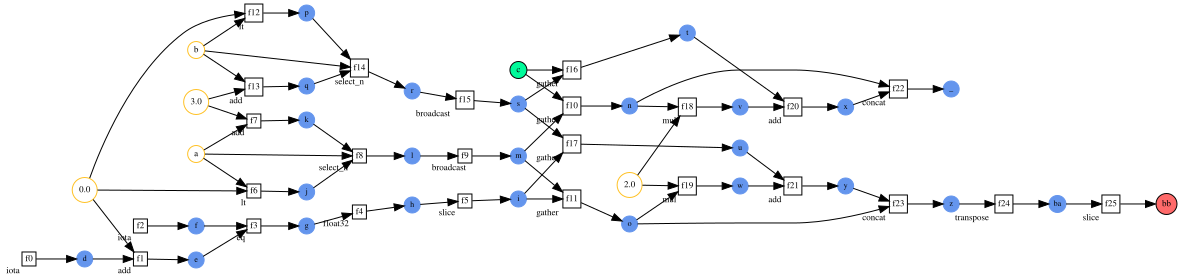

In [40]:
g = JaxprGraph(jac_jaxpr.jaxpr.invars,jac_jaxpr.jaxpr.constvars,  jac_jaxpr.jaxpr.outvars, jac_jaxpr.eqns)
g

In [32]:
def _extract_call_jaxpr(primitive, params):
  if not (primitive.call_primitive or primitive.map_primitive):
    return None, params
  else:
    params = dict(params)
    return params.pop("call_jaxpr"), params

def _dependent_variables(jaxpr, dependent=None):
  """Returns the set of variables in the jaxpr that depend on the input vars."""
  if dependent is None:
    dependent = set(jaxpr.invars)

  for eqn in jaxpr.eqns:
    # If primitive is an xla_call, get subexpressions and evaluate recursively
    call_jaxpr, _ = _extract_call_jaxpr(eqn.primitive, eqn.params)
    if call_jaxpr:
      to_name = dict(zip(eqn.invars, call_jaxpr.invars))
      arg_dependence = set(to_name[v] for v in eqn.invars if v in dependent)
      subjaxpr_dependent = _dependent_variables(call_jaxpr, arg_dependence)
      from_name = dict(zip(call_jaxpr.outvars, eqn.outvars))
      dependent.update(from_name[v] for v in call_jaxpr.outvars
                       if v in subjaxpr_dependent)
    else:
      for v in eqn.invars:
        if isinstance(v, jax.core.Var) and v in dependent:
          dependent.update(eqn.outvars)

  return dependent

In [39]:
_dependent_variables(jac_jaxpr.jaxpr)

{_, c, n, t, v, x}

In [2]:
f_inv = inverse(f)

In [3]:
out = f(x)
input = f_inv(out)

In [4]:
x

Array([0., 1., 2.], dtype=float32)

In [5]:
out

Array([2., 4., 5.], dtype=float32)

In [6]:
input

[Array([0., 1., 2.], dtype=float32)]

In [2]:

def f(x0):
    x = jnp.tanh(x0)
    y = jnp.exp(x) + 1
    return y

f_inv = inverse(f)

x = jnp.ones(1)*2

In [3]:
out = f(x)
input = f_inv(out)
input

Array([2.], dtype=float32)

In [26]:
jax.make_jaxpr(f)(x)

{ lambda ; a:f32[1]. let
    b:f32[1] = tanh a
    c:f32[1] = exp b
    d:f32[1] = add c 2.0
    e:f32[1] = pjit[
      jaxpr={ lambda ; f:f32[1]. let g:f32[1] = logistic f in (g,) }
      name=sigmoid
    ] d
  in (e,) }

In [27]:
jax.make_jaxpr(f)(x).eqns[-1].outvars

[e]

In [28]:
jax.lax.pow_p.bind(x, 2.)

Array([1.], dtype=float32)

In [29]:
out = f(x)
input = f_inv(out)

In [20]:
jax.grad(f_inv)(jnp.ones(1))

NotImplementedError: reduce_sum is not invertible!

In [12]:
x

Array([1.], dtype=float32)

In [13]:
input

[Array(1.0000029, dtype=float32)]

In [22]:
theta = 0.1

def dx(t, x):
    return t*0.1 * x

def f(x0):
    x = x0
    for i in range(5):
        x = x + dx(i, x)
    return x

f_inv = inverse(f)

x = jnp.arange(3, dtype=jnp.float32)

In [23]:
x = 1. 

x = x + 0.1 * x
x = x - 0.1 * x
x

0.9900000000000001

In [24]:
jax.make_jaxpr(f)(x)

{ lambda ; a:f32[]. let
    b:f32[] = mul 0.0 a
    c:f32[] = add a b
    d:f32[] = mul 0.1 c
    e:f32[] = add c d
    f:f32[] = mul 0.2 e
    g:f32[] = add e f
    h:f32[] = mul 0.30000000000000004 g
    i:f32[] = add g h
    j:f32[] = mul 0.4 i
    k:f32[] = add i j
  in (k,) }

In [25]:
out = f(x)
input = f_inv(out)

{k: 2.3783760000000003}
[(9, 0.0)]


NotImplementedError: Cannot invert a:f32[] = add b c

In [20]:
input

[Array([0., 1., 2.], dtype=float32)]